# TAKE HOME TEST (Food Delivery Times)

##### Yumita

# Library yang digunakan

In [1]:
# Library yang digunakan
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import math

### 1. Import Data

In [2]:
# Menampilkan semua kolom dan 5 data teratas
pd.set_option('display.max_columns', None)
df = pd.read_csv("Food_Delivery_Times.csv") 
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


### 2. Data Exploration

#### 1. Cek info dasar data

In [3]:
# Melihat info dasar data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [4]:
# Melihat ukuran data
df.shape

(1000, 9)

Penjelasan :
- Dataset food delivery times terdiri dari 9 kolom dengan jumlah barisnya 1.000 baris

#### 2. Cek statistika deskripsi dari data

In [5]:
# Mengecek nilai statistik kolom numerik
df.describe().round(2)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.00,1000.00,1000.00,970.00,1000.00
mean,500.50,10.06,16.98,4.58,56.73
std,288.82,5.70,7.20,2.91,22.07
min,1.00,0.59,5.00,0.00,8.00
25%,250.75,5.11,11.00,2.00,41.00
50%,500.50,10.19,17.00,5.00,55.50
75%,750.25,15.02,23.00,7.00,71.00
max,1000.00,19.99,29.00,9.00,153.00


In [6]:
# Mengecek nilai statistik kolom kategori
df.describe(include='object')

,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
count,970,970,970,1000
unique,5,3,4,3
top,Clear,Medium,Morning,Bike
freq,470,390,308,503


#### 3. Cek type data

In [7]:
# Mengecek type data masing-masing kolom
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

Dari hasil output diatas type data setiap kolomya sudah sesuai

#### 4. Cek Konsistensi Data

##### a. Cek typo data

In [8]:
# Proporsi data kategori untuk di cek typo nya
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in cat_cols :
    print(f'\nDistribusi {col}')
    print(df[col].value_counts(dropna=False))


Distribusi Weather
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Distribusi Traffic_Level
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Distribusi Time_of_Day
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64

Distribusi Vehicle_Type
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


#### 5. Mengecek missing value data

In [9]:
# Mengecek jumlah nilai missing data
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Keterangan :
Terdapat nilai missing value pada beberapa kolom yaitu kolom weather, traffic level, time of day, dan courier experience yrs

In [10]:
# mengecek row yang terdapat missing value
df[df.isnull().any(axis=1)]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
14,939,2.80,Clear,High,Morning,Scooter,10,NaN,33
24,211,11.20,Clear,Medium,Morning,Bike,23,NaN,73
42,313,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,494,4.17,NaN,Low,Evening,Scooter,5,1.0,22
...,...,...,...,...,...,...,...,...,...
974,414,11.68,Clear,NaN,Afternoon,Scooter,25,7.0,70
976,344,8.96,Snowy,NaN,Morning,Car,6,5.0,51
987,331,7.44,Rainy,Low,Evening,Bike,27,NaN,53
988,215,14.39,Rainy,Medium,Morning,Scooter,6,NaN,50


In [11]:
# mengecek jumlah missing dan jumlah barisnya
df.isnull().sum(axis=1).value_counts()

0    883
1    114
2      3
Name: count, dtype: int64

Keterangan :
- Terdapat missing value pada 4 kolom data dengan persentase missing sebanyak 3%.
- Dataset yang memiliki 0 missing yaitu 883 baris, 1 missing terdapat 114 baris dan 2 missing 3 baris. Jadi data bersih hanya 883 baris
- Tidak ada indikasi bahwa 30 missing weather, traffic, time_of_day an courier experienence berasal dari record yang sama
- Karena proporsi missingnya kecil dan untuk menghindari perubahan distribusi kategori asli, nilai yang  baru diisi menggunakan kategori baru "unknown"

#### 6. Cek nilai duplicate data

In [12]:
# Mengecek jumlah nilai duplikat
duplicate = df.duplicated().sum()
print(duplicate)

0


In [13]:
# mengecek duplicate order id
df['Order_ID'].duplicated().sum()

np.int64(0)

In [14]:
# mengecek nilai unik order id
df['Order_ID'].nunique()

1000

In [15]:
# menghitung panjang data
len(df)

1000

Keterangan : 
- Tidak terdapat data yang duplicate secara keseluruhan data yang ada
- Order id unik antara setiap pelanggan

#### 7. Mengecek outlier data

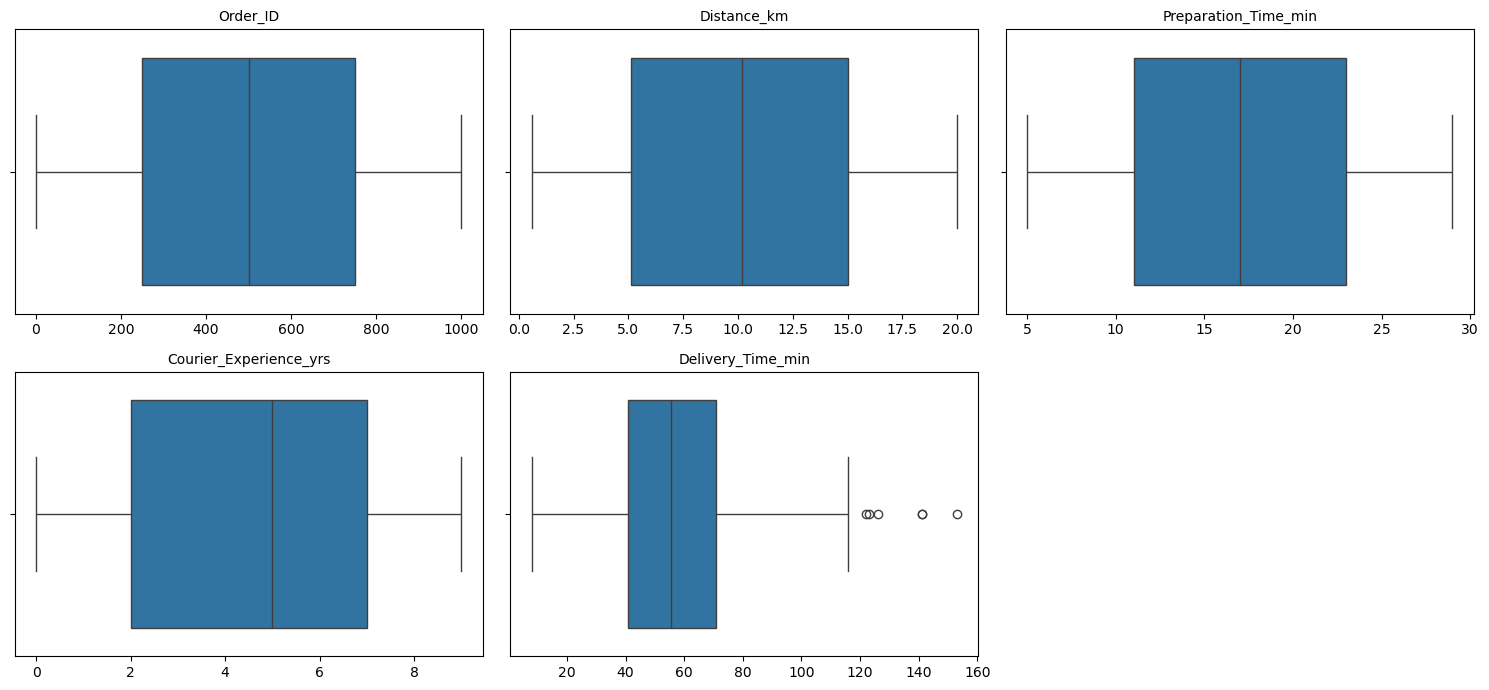

In [16]:
# Mengecek visualisasi dengan boxplot untuk nilai outlier data
num_cols = ['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

# 1. Tentukan mau berapa kolom ke samping
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols) # Menghitung otomatis butuh berapa baris ke bawah

# 2. Buat kanvas besar (figure) dengan ukuran grid baris x kolom yang ditentukan
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 3.5))

# 3. Ratakan koordinat axes (dari matriks 2D menjadi 1D) biar gampang di-looping
axes = axes.flatten()

# 4. Loop untuk menggambar boxplot di setiap slot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i]) # Perhatikan ada tambahan ax=axes[i]
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('') # Opsional: mengosongkan label x biar gak tumpang tindih

# 5. Karena 5x3 = 15 slot sedangkan kolom kita cuma 13, hapus 2 slot kosong sisanya
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Atur layout agar rapi dan tidak tumpang tindih, lalu tampilkan
plt.tight_layout()
plt.show()

In [17]:
# Menghitung total seluruh baris untuk nilai outlier dan jumlah outlier serta persentasenya
# 1. Hitung total baris data
total_data = df.shape[0]

# 2. Daftar kolom numerik yang dicek outlier-nya
kolom_numerik = ['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

# 3. Lakukan perhitungan dengan looping dan simpan hasilnya ke list
outlier_summary = []

for col in kolom_numerik:
    # Hitung Q1, Q3, dan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Hitung batas bawah dan batas atas
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Hitung jumlah dan persentase outlier
    jumlah_outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    pct_outlier = (jumlah_outlier / total_data) * 100
    
    # Masukkan data ke dalam list format dictionary
    outlier_summary.append({
        'Nama Kolom': col,
        'Batas Bawah': round(lower_bound, 2),
        'Batas Atas': round(upper_bound, 2),
        'Jumlah Outlier (Baris)': jumlah_outlier,
        'Persentase Outlier (%)': f"{pct_outlier:.2f}%"
    })

# 4. Ubah list menjadi DataFrame agar berbentuk tabel
df_outlier = pd.DataFrame(outlier_summary)

# 5. Tampilkan tabelnya
df_outlier

,Nama Kolom,Batas Bawah,Batas Atas,Jumlah Outlier (Baris),Persentase Outlier (%)
0,Order_ID,-498.50,1499.50,0,0.00%
1,Distance_km,-9.76,29.89,0,0.00%
2,Preparation_Time_min,-7.00,41.00,0,0.00%
3,Courier_Experience_yrs,-5.50,14.50,0,0.00%
4,Delivery_Time_min,-4.00,116.00,6,0.60%


In [18]:
Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5*IQR

df[df['Delivery_Time_min'] > upper]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153
452,394,15.64,Rainy,Low,NaN,Bike,20,4.0,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122


Interpretasi :
- Metode IQR menemukan 6 observasi outlier (0.6%) pada variabel delivery_time_min
- Namun setelah pengecekan lebih lanjut, seluruh observasi tersebut memiliki karakteristik yang masih masuk akal secara operasional, seperti jarak pengiriman yang relatif jauh 14-19 km dalam waktu persiapan yang lama hingga 29 menit
- Oleh karena itu, outlier dipertahankan karena merepresentasikan kondisi bisnis yang valid dan berpotensi memberikan insight penting mengenai faktor-faktor yang menyebabkan keterlambatan pengiriman

### 3. Data Cleaning

In [19]:
# Membuat df baru 
df_clean = df.copy()

#### 1. Menghandling missing value

##### a. Handling missing value kolom kategori

In [20]:
# Mengisi missing value untuk kolom kategori dengan unknown
cat_cols = ['Weather','Traffic_Level','Time_of_Day']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

In [21]:
# Menampilkan jumlah data masing-masing kolom yang sudah di handling missingnya
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day']

for col in cat_cols :
    print(f'\nDistribusi {col}')
    print(df_clean[col].value_counts(dropna=False))


Distribusi Weather
Weather
Clear      470
Rainy      204
Foggy      103
Snowy       97
Windy       96
Unknown     30
Name: count, dtype: int64

Distribusi Traffic_Level
Traffic_Level
Medium     390
Low        383
High       197
Unknown     30
Name: count, dtype: int64

Distribusi Time_of_Day
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Unknown       30
Name: count, dtype: int64


Keterangan : untuk ketiga kolom tersebut nilai missing valuenya sudah dihandling dan diganti dengan "unknown"

##### b. Handling missing value kolom numerik

In [22]:
# mengecek statistika kolom courier experience yrs
round(df['Courier_Experience_yrs'].describe(), 2)

count    970.00
mean       4.58
std        2.91
min        0.00
25%        2.00
50%        5.00
75%        7.00
max        9.00
Name: Courier_Experience_yrs, dtype: float64

In [23]:
# mengecek distribusi data kolom courier experience yrs
df['Courier_Experience_yrs'].value_counts().sort_index()

Courier_Experience_yrs
0.0     91
1.0    107
2.0     99
3.0     80
4.0     94
5.0     90
6.0    109
7.0     91
8.0    101
9.0    108
Name: count, dtype: int64

In [24]:
# menghandling missing value mengisi dengan nilai median
df_clean['Courier_Experience_yrs'] = df_clean['Courier_Experience_yrs'].fillna(
    df_clean['Courier_Experience_yrs'].median())

In [25]:
# mengecek distribusi data kolom courier experience yrs
df_clean['Courier_Experience_yrs'].value_counts().sort_index()

Courier_Experience_yrs
0.0     91
1.0    107
2.0     99
3.0     80
4.0     94
5.0    120
6.0    109
7.0     91
8.0    101
9.0    108
Name: count, dtype: int64

### 4. Data Manipulation

#### FEATURING ENGINEERING

#### 1. Menambahkan Distance Category

In [26]:
# Menambahkan kolom distance category
df_clean['Distance_Category'] = pd.cut(
    df_clean['Distance_km'],
    bins=[0,5,10,15,20],
    labels=[
        'Short',
        'Medium',
        'Long',
        'Very Long'
    ])

In [27]:
df_clean['Distance_Category'].value_counts()

Distance_Category
Long         260
Very Long    251
Short        248
Medium       241
Name: count, dtype: int64

Kategori :
- Short = 0-5 km
- Medium = 5-10 km
- Long = 10-15 km
- Very long = 15-20 km

#### 2. Menambahkan experience group

In [28]:
# Menambahkan kolom experience group
df_clean['Experience_Group'] = pd.cut(
    df_clean['Courier_Experience_yrs'],
    bins=[-1,2,5,9],
    labels=[
        'Junior',
        'Mid-Level',
        'Senior'
    ])

Kategori :
- Junior = 0-2 tahun
- Mid-Level = 3-5 tahun
- Senior = 6-9 tahun

In [29]:
df_clean['Experience_Group'].value_counts()

Experience_Group
Senior       409
Junior       297
Mid-Level    294
Name: count, dtype: int64

#### 3. Menambahkan kolom delay level

In [30]:
# Menambahkan kolom delay level
df_clean['Delay_Level'] = pd.cut(
    df_clean['Delivery_Time_min'],
    bins=[0,30,60,90,200],
    labels=[
        'Fast',
        'Normal',
        'Slow',
        'Very Slow'
    ])

Kategori :
- 0-30 menit     = Fast
- 31-60 menit    = Normal
- 61-90 menit    = Slow
- lebih dari 90 menit      = Very Slow

In [31]:
df_clean['Delay_Level'].value_counts()

Delay_Level
Normal       467
Slow         340
Fast         118
Very Slow     75
Name: count, dtype: int64

### 5. Pengecekan Struktur Data Setelah Cleaning

#### 1. Cek struktur data

In [32]:
# Cek info awal data setelah cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Order_ID                1000 non-null   int64   
 1   Distance_km             1000 non-null   float64 
 2   Weather                 1000 non-null   object  
 3   Traffic_Level           1000 non-null   object  
 4   Time_of_Day             1000 non-null   object  
 5   Vehicle_Type            1000 non-null   object  
 6   Preparation_Time_min    1000 non-null   int64   
 7   Courier_Experience_yrs  1000 non-null   float64 
 8   Delivery_Time_min       1000 non-null   int64   
 9   Distance_Category       1000 non-null   category
 10  Experience_Group        1000 non-null   category
 11  Delay_Level             1000 non-null   category
dtypes: category(3), float64(2), int64(3), object(4)
memory usage: 73.9+ KB


Interpretasi :
- Setelah dilakukan data cleaning terdapat 3 kolom tambahan untuk membantu dan digunakan dalam analisis dataset

#### 2. Cek statistika deskripsi dari data

In [33]:
# Mengecek nilai statistik kolom numerik
df_clean.describe().round(2)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,10.06,16.98,4.59,56.73
std,288.82,5.70,7.20,2.87,22.07
min,1.00,0.59,5.00,0.00,8.00
25%,250.75,5.11,11.00,2.00,41.00
50%,500.50,10.19,17.00,5.00,55.50
75%,750.25,15.02,23.00,7.00,71.00
max,1000.00,19.99,29.00,9.00,153.00


In [34]:
# Mengecek nilai statistik kolom kategori
df_clean.describe(include='object')

,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
count,1000,1000,1000,1000
unique,6,4,5,3
top,Clear,Medium,Morning,Bike
freq,470,390,308,503


In [35]:
# Mengecek nilai statistik kolom kategori
df_clean.describe(include='category')

,Distance_Category,Experience_Group,Delay_Level
count,1000,1000,1000
unique,4,3,4
top,Long,Senior,Normal
freq,260,409,467


#### 3. Cek missing value data

In [36]:
# Mengecek jumlah nilai missing data
df_clean.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
Distance_Category         0
Experience_Group          0
Delay_Level               0
dtype: int64

#### 4. Cek duplicate data

In [37]:
# Mengecek jumlah nilai duplikat
duplicate = df_clean.duplicated().sum()
print(duplicate)

0


### 6. Download Data Setelah Cleaning

In [86]:
# Mendownload file dataset setelah cleaning
df_clean.to_csv('Food_Delivery_Times_Clean.csv', index=False)

### 7. Exploratory Data Analysis (EDA)

In [39]:
# Mengatur warna untuk chart yang digunakan
BLUE = '#1f77b4'

sns.set_style("whitegrid")

#### UNIVARIATE ANALYSIS

#### 1. Numerical Variabel

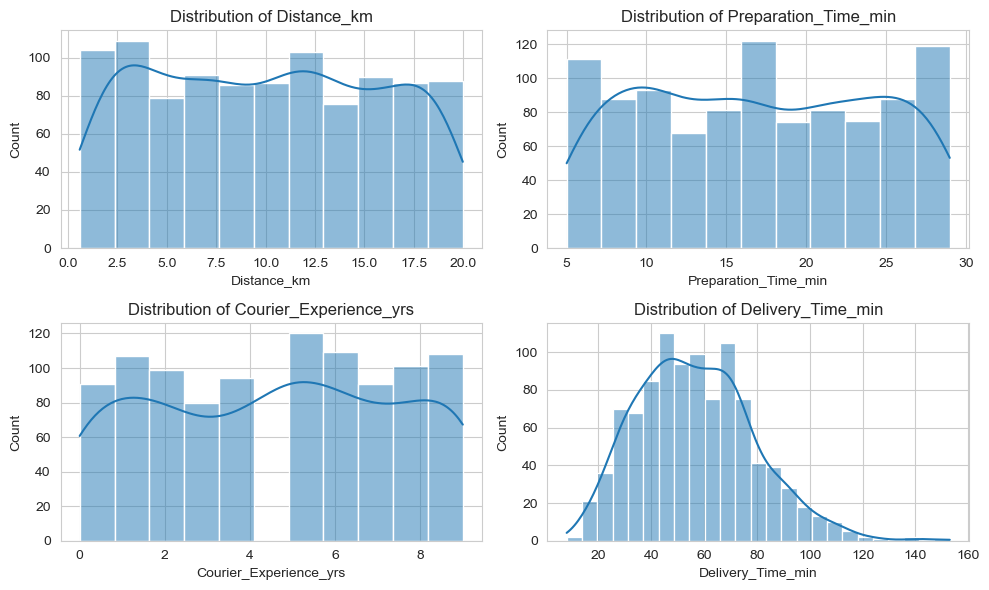

In [40]:
num_cols = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs',
    'Delivery_Time_min'
]

fig, axes = plt.subplots(2,2, figsize=(10,6))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(
        data=df_clean,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

INTERPRETASI :
1. Distribution of Distance_km
- **Bentuk Distribusi** : Uniform (Seragam / Merata)

- **Interpretasi** : Jarak pengiriman tersebar cukup merata di rentang 0 hingga 20 km. Jumlah pesanan untuk jarak pendek, menengah, maupun jauh relatif sama (berkisar antara 80–100 pengiriman per bin).

2. Distribution of Preparation_Time_min
- **Bentuk Distribusi**: Uniform dengan beberapa puncak di batas/tengah

- **Interpretasi** : Waktu penyiapan barang/makanan berkisar dari 5 hingga 30 menit. Terdapat frekuensi yang sedikit lebih tinggi di sekitar 5 menit, 16–18 menit, dan mendekati 28–30 menit, namun secara umum sebarannya cukup merata.

3. Distribution of Courier_Experience_yrs
- **Bentuk Distribusi** : Bimodal / Multimodal (Merata secara umum)

- **Interpretasi** : Pengalaman kurir mencakup rentang 0 hingga 9 tahun. Jumlah kurir pemula (0–3 tahun), menengah (5–6 tahun), dan senior (7–9 tahun) terbagi relatif seimbang, dengan sedikit kekosongan di rentang 4–5 tahun.

4. Distribution of Delivery_Time_min
- **Bentuk Distribusi** : Right-skewed (Miring ke kanan / Mencong Positif).

- **Interpretasi** : 
    - Mayoritas pengiriman membutuhkan waktu antara 40 hingga 80 menit (puncak tertinggi ada di rentang 45–70 menit).
    - Sebagian besar pengiriman selesai di bawah 90 menit, namun terdapat tail (ekor) ke arah kanan hingga melebihi 120–140 menit yang mengindikasikan adanya beberapa pencilan (outlier) atau pengiriman yang mengalami keterlambatan ekstrem.

#### 2. Categorical variabel

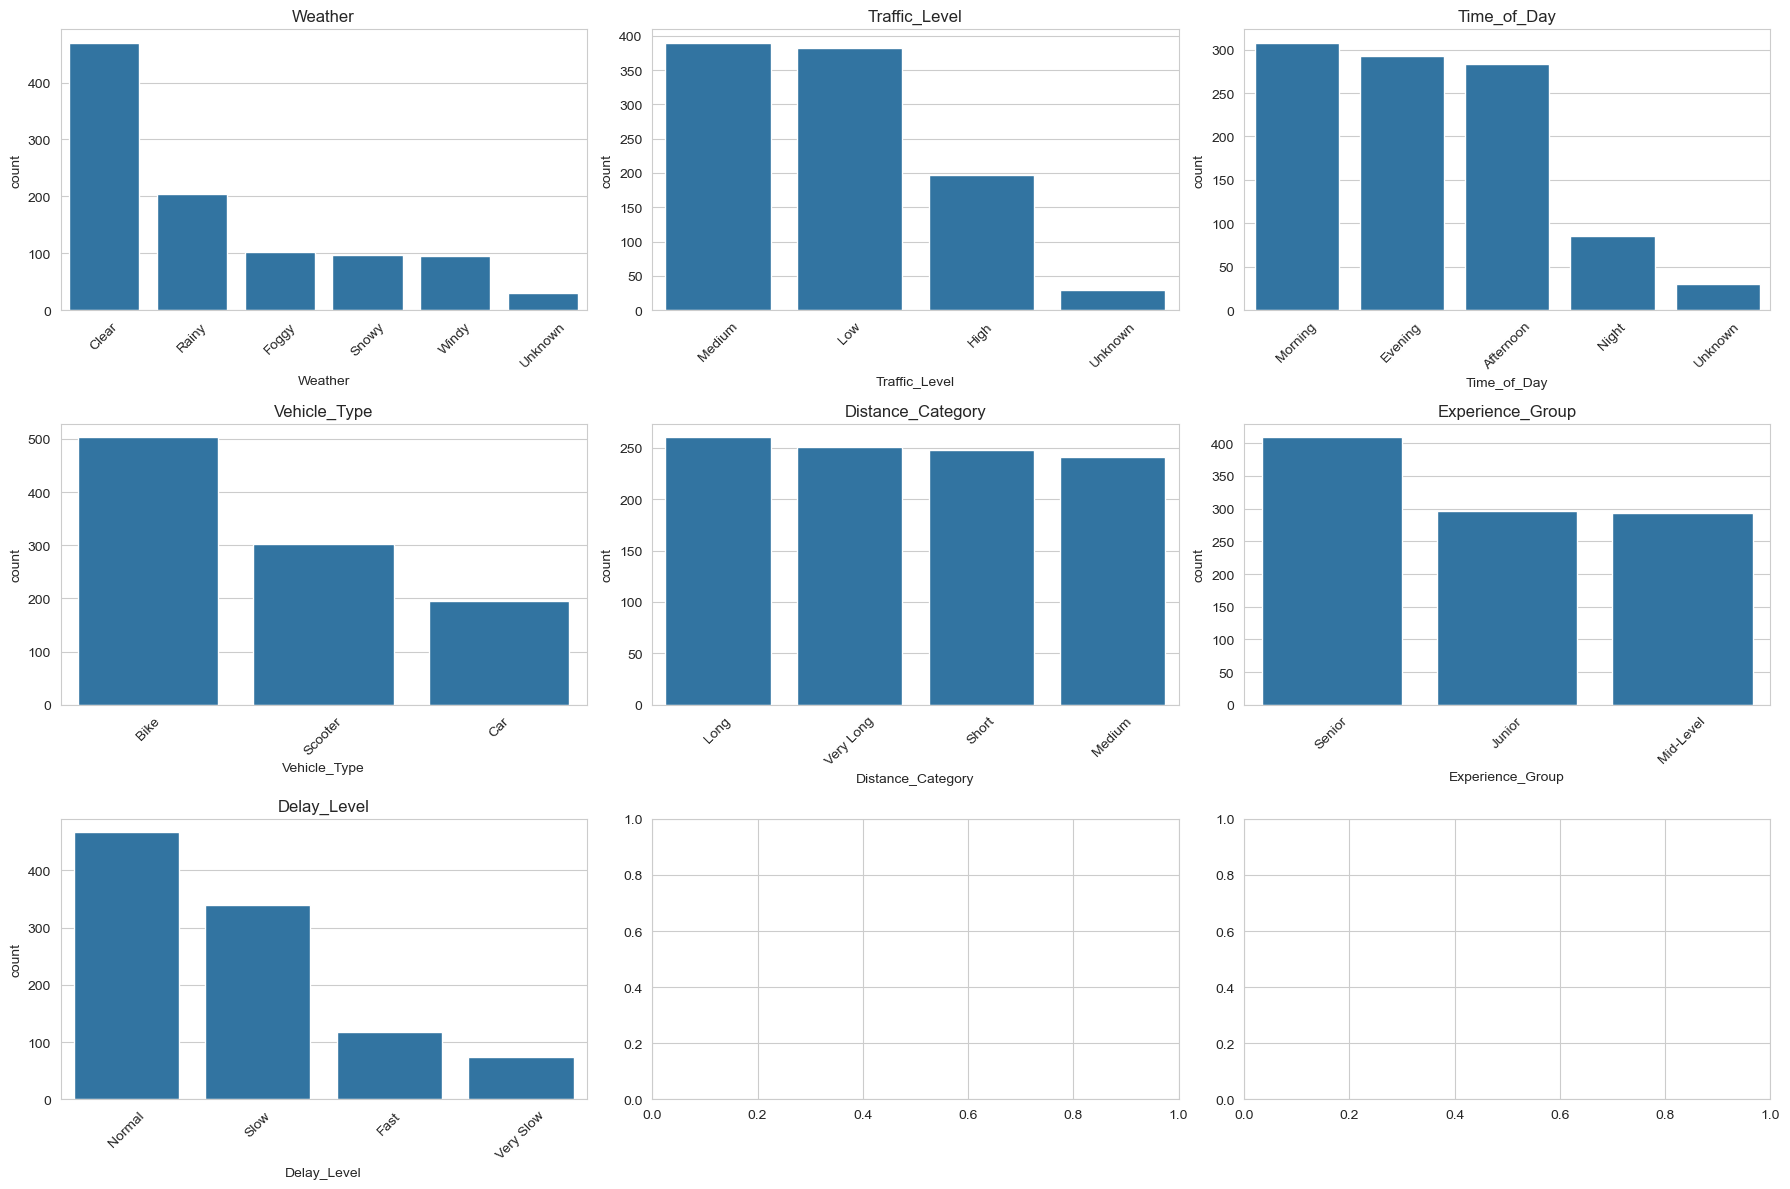

In [41]:
cat_cols = [
    'Weather',
    'Traffic_Level',
    'Time_of_Day',
    'Vehicle_Type',
    'Distance_Category',
    'Experience_Group',
    'Delay_Level'
]

fig, axes = plt.subplots(3,3, figsize=(18,12))

for ax, col in zip(axes.flatten(), cat_cols):

    sns.countplot(
        data=df_clean,
        x=col,
        ax=ax,
        order=df_clean[col].value_counts().index
    )

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

INTERPRETASI :
1. **Weather (cuaca)**
   - Saat proses pengiriman barang cuaca dominan cerah dan cuaca hujan di posisi kedua
2. **Traffic Level (tingkat lalu lintas)**
   - Sebagian besar pengiriman terjadi pada kondisi medium dan low traffic
3. **Time of day (waktu pengiriman)**
   - Jam operasional aktif terbagi cukup merata pada pagi, sore, dan siang hari. Serta pengiriman paling sedikit terjadi pada malam hari
4. **Vehicle type (jenis kendaraan)**
   - Motor menjadi transportasi utama yang digunakan dalam pengiriman barang
5. **Distance category (kategori jarak)**
   - Serabannya sangat merata (uniform), semua kategori jarak memiliki frekuensi yang hampir identik atau sama
6. **Experience group (Pengalaman kurir)**
   - Kurir tingka senior menjadi kelompok paling banyak
7. **Delay level (Tingkat keterlambatan)**
   - Sebagian besar pengiriman berjalan normal atau agak terlambat. Pengiriman kategori sangat cepat dan sangat lambat memiliki frekuensi yang relatif kecil

#### BIVARIATE ANALYSIS

#### 1. Distance vs Delivery Time

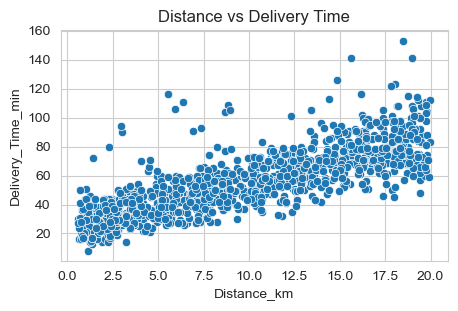

In [42]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_clean,
    x='Distance_km',
    y='Delivery_Time_min'
)

plt.title('Distance vs Delivery Time')
plt.show()

INTERPRETASI :
- Grafik scatterplot menunjukkan adanya korelasi positif yang kuat antara jarak pengiriman (Distance_km) dan waktu tempuh (Delivery_Time_min), di mana semakin jauh jaraknya secara umum waktu pengiriman akan semakin lama
- Terdapat sebaran titik dan beberapa outlier (pencilan)—seperti pengiriman jarak pendek yang memakan waktu hingga di atas 100 menit—yang mengindikasikan adanya faktor luar lain seperti kemacetan, cuaca, atau durasi penyiapan barang yang turut memengaruhi lama pengiriman.

#### 2. Preparation vs Delivery

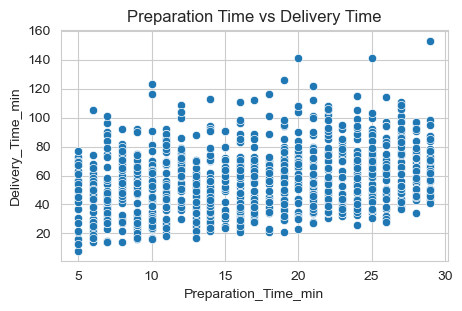

In [43]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_clean,
    x='Preparation_Time_min',
    y='Delivery_Time_min'
)

plt.title('Preparation Time vs Delivery Time')
plt.show()

INTERPRETASI :
- Grafik scatterplot menunjukkan korelasi positif yang sangat lemah atau cenderung acak antara waktu penyiapan (Preparation_Time_min) dan total waktu pengiriman (Delivery_Time_min)
- Sebaran titik yang relatif merata dari 5 hingga 30 menit menunjukkan bahwa lama penyiapan barang/makanan bukanlah faktor utama yang menentukan total waktu pengiriman secara signifikan, di mana variabel lain seperti jarak dan kondisi lalu lintas kemungkinan memiliki pengaruh yang lebih dominan

#### 3. Experience vs Delivery

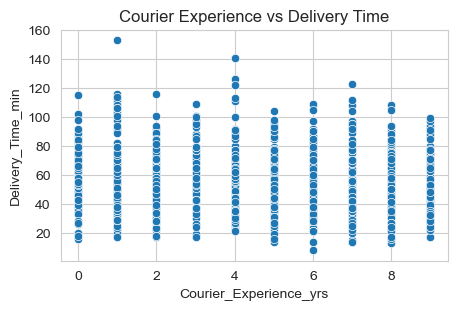

In [44]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_clean,
    x='Courier_Experience_yrs',
    y='Delivery_Time_min'
)

plt.title('Courier Experience vs Delivery Time')
plt.show()

INTERPRETASI :
- Grafik scatterplot menunjukkan tidak adanya korelasi yang jelas (hubungan netral/acak) antara pengalaman kurir (Courier_Experience_yrs) dan waktu pengiriman (Delivery_Time_min)
- Rentang waktu pengiriman terpantau serupa—sebagian besar berkisar antara 20 hingga 100 menit—baik untuk kurir pemula (0–2 tahun) maupun kurir senior (7–9 tahun)
- Hal ini mengindikasikan bahwa bertambahnya tahun pengalaman kurir tidak secara otomatis mempercepat waktu tempuh pengiriman, karena faktor eksternal seperti jarak tempuh, kondisi lalu lintas, dan tingkat kemacetan jauh lebih menentukan durasi pengiriman

#### 4. Pairplot Numerical

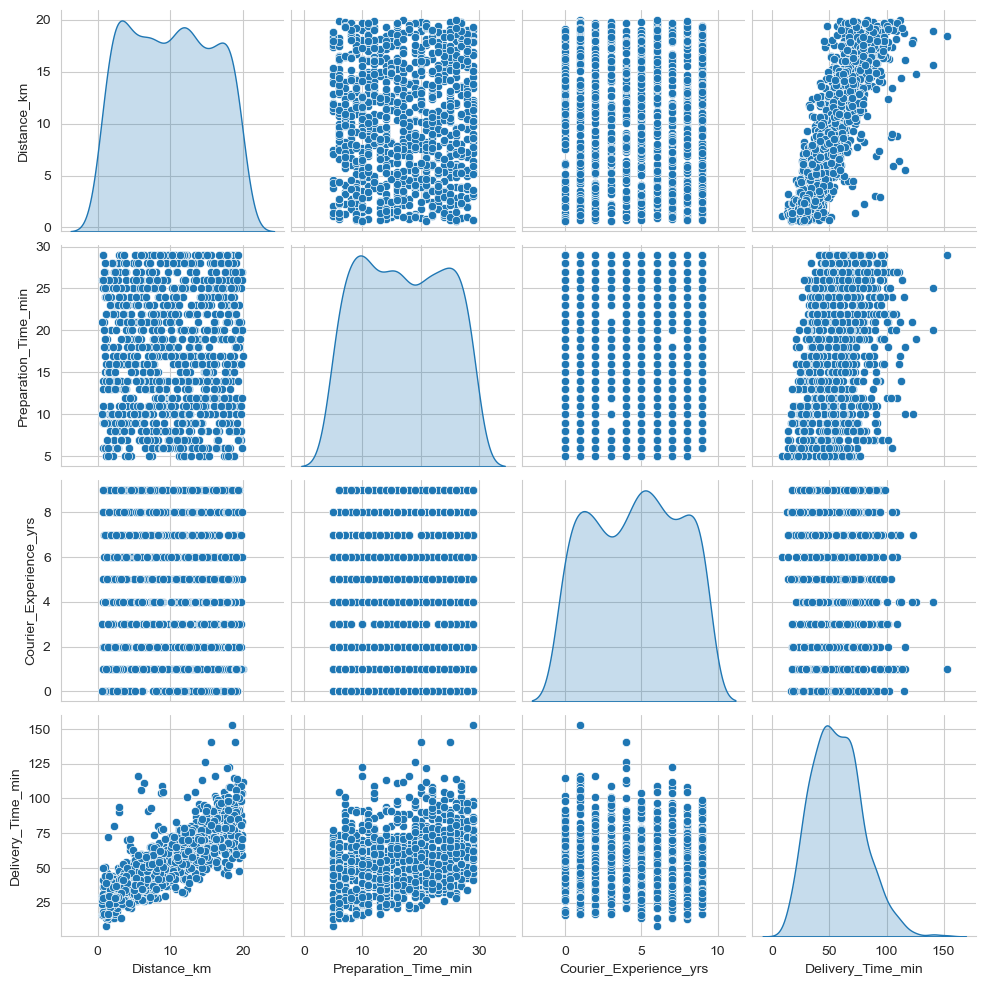

In [45]:
num_cols = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs',
    'Delivery_Time_min'
]

sns.pairplot(
    df_clean[num_cols],
    diag_kind='kde'
)

plt.show()

**INTERPRETASI** :
Matriks pairplot menunjukkan bahwa dari seluruh variabel fitur, hanya jarak (Distance_km) yang memiliki korelasi positif linear yang signifikan terhadap waktu pengiriman (Delivery_Time_min), di mana durasi pengiriman secara konsisten meningkat seiring bertambahnya jarak. Sementara itu, variabel waktu penyiapan (Preparation_Time_min) dan pengalaman kurir (Courier_Experience_yrs) menunjukkan sebaran titik yang cenderung acak tanpa pola linear yang jelas terhadap Delivery_Time_min maupun terhadap variabel lainnya. Secara keseluruhan, pairplot ini mengonfirmasi bahwa jarak tempuh merupakan prediktor utama bagi durasi pengiriman, sedangkan fitur lainnya independen satu sama lain.

#### 5. Weather vs Delivery time

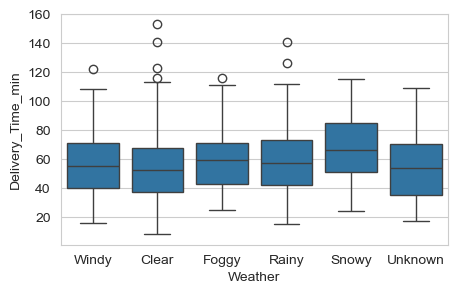

In [46]:
plt.figure(figsize=(5,3))

sns.boxplot(
    data=df_clean,
    x='Weather',
    y='Delivery_Time_min'
)

plt.show()

**INTERPRETASI** : Diagram boxplot menunjukkan bahwa kondisi cuaca Snowy (bersalju) menghasilkan median waktu pengiriman paling tinggi (sekitar 65–70 menit) dibandingkan kondisi cuaca lainnya yang memiliki median relatif stabil di kisaran 50–60 menit. Cuaca Clear (cerah) memiliki nilai median waktu tempuh yang paling rendah, namun memicu variabilitas yang cukup ekstrem dengan ditemukannya beberapa outlier keterlambatan hingga mencapai 140–150+ menit. Secara keseluruhan, cuaca ekstrem seperti salju cenderung memperlambat durasi pengiriman secara konsisten, sementara cuaca cerah dan hujan memiliki rentang keterlambatan puncak yang lebih lebar.

#### 6. Traffic vs Delivery time

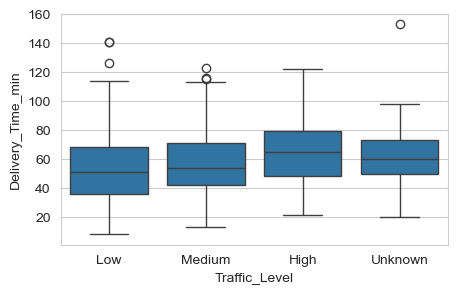

In [47]:
plt.figure(figsize=(5,3))

sns.boxplot(
    data=df_clean,
    x='Traffic_Level',
    y='Delivery_Time_min'
)

plt.show()

**INTERPRETASI** : Diagram boxplot menunjukkan bahwa tingkat kepadatan lalu lintas (Traffic_Level) berbanding lurus dengan durasi pengiriman, di mana kategori High memiliki nilai median waktu tempuh tertinggi (sekitar 65 menit) dibandingkan kategori Medium (55 menit) dan Low (50 menit). Selain itu, batas bawah waktu pengiriman pada kondisi lalu lintas padat (High) berada di sekitar 20 menit, yang secara signifikan lebih tinggi dibanding kondisi lancar (Low) yang bisa mencapai di bawah 10 menit. Meskipun tingkat kemacetan tinggi meningkatkan rata-rata waktu tempuh, beberapa outlier keterlambatan ekstrem hingga melebihi 140–150 menit justru terdeteksi pada kondisi Low dan Unknown, yang mengindikasikan adanya faktor kendala lain di luar kepadatan jalan.

#### 7. Vehicle vs Delivery time

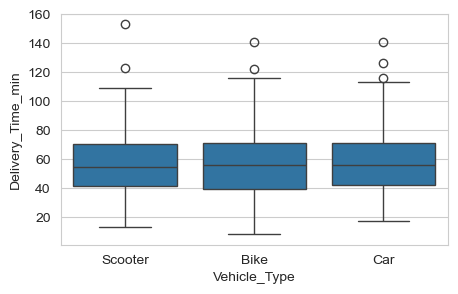

In [48]:
plt.figure(figsize=(5,3))

sns.boxplot(
    data=df,
    x='Vehicle_Type',
    y='Delivery_Time_min'
)

plt.show()

**INTERPRETASI** : Diagram boxplot menunjukkan bahwa jenis kendaraan (Scooter, Bike, dan Car) memiliki pengaruh yang hampir identik terhadap waktu pengiriman (Delivery_Time_min). Ketiga jenis kendaraan tersebut memiliki nilai median waktu pengiriman yang sama di kisaran 55 menit, serta rentang antar-kuartil (IQR) yang sejajar antara 40 hingga 70 menit. Meskipun Bike memiliki nilai minimum waktu tempuh sedikit lebih cepat (dibawah 10 menit) dibanding Car (~18 menit), ketiga kategori ini sama-sama memiliki beberapa titik outlier keterlambatan yang mencapai 120 hingga 150+ menit. Hal ini mengindikasikan bahwa pilihan kendaraan tidak menjadi faktor pembeda utama dalam durasi waktu pengiriman.

#### 8. Time of day vs Delivery time

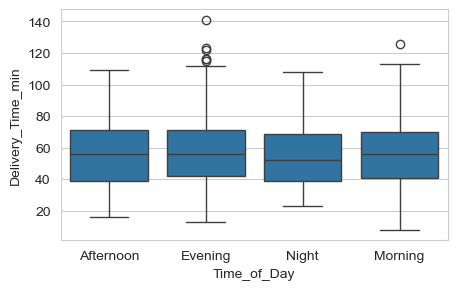

In [49]:
plt.figure(figsize=(5,3))

sns.boxplot(
    data=df,
    x='Time_of_Day',
    y='Delivery_Time_min'
)

plt.show()

**INTERPRETASI** : Diagram boxplot menunjukkan bahwa waktu pengiriman (Delivery_Time_min) memiliki sebaran yang sangat konsisten di sepanjang berbagai waktu dalam sehari (Afternoon, Evening, Night, dan Morning), dengan nilai median yang hampir seragam di kisaran 50–55 menit. Rentang antar-kuartil (IQR) untuk keempat kategori juga berada pada rentang yang relatif mirip, yaitu antara 40 hingga 70 menit. Perbedaan kecil terlihat pada pengiriman malam hari (Night) yang memiliki nilai minimum lebih tinggi (~22 menit) dibanding pagi/sore, serta pengiriman malam/sore (Evening) yang mencatatkan beberapa outlier keterlambatan hingga melebihi 120–140 menit. Secara keseluruhan, waktu operasional dalam sehari tidak secara signifikan memengaruhi durasi rata-rata pengiriman.

#### MULTIVARIATE ANALYSIS

#### 1. Correlation Heatmap

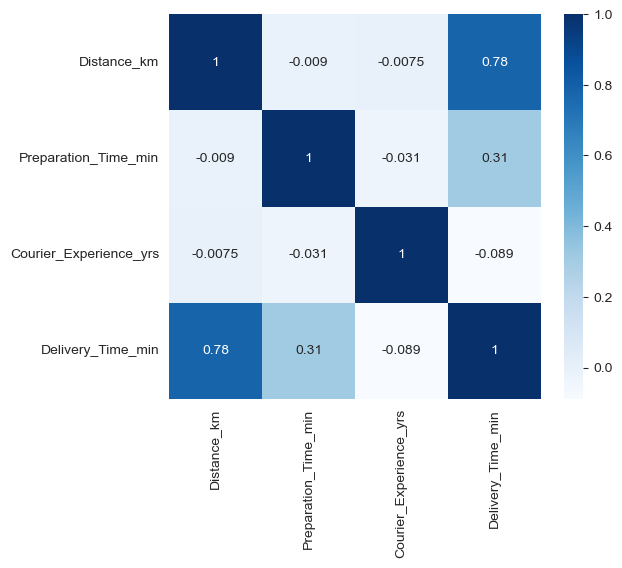

In [50]:
plt.figure(figsize=(6,5))

corr = df_clean[
    [
        'Distance_km',
        'Preparation_Time_min',
        'Courier_Experience_yrs',
        'Delivery_Time_min'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.show()

**INTERPRETASI** : Matriks korelasi (heatmap) menunjukkan bahwa jarak pengiriman (Distance_km) memiliki korelasi positif yang sangat kuat terhadap waktu pengiriman (Delivery_Time_min) dengan nilai r = 0,78, menjadikannya faktor penentu utama durasi pengiriman. Sementara itu, waktu penyiapan (Preparation_Time_min) memiliki korelasi positif sedang (r = 0,31), sedangkan pengalaman kurir (Courier_Experience_yrs) tidak memiliki hubungan yang signifikan atau cenderung netral (r = -0,089). Korelasi antar-variabel independen lainnya terpantau mendekati nol, yang mengindikasikan tidak adanya masalah multikolinearitas dalam data.

#### 2. Traffic dan Vehicle --> Delivery time

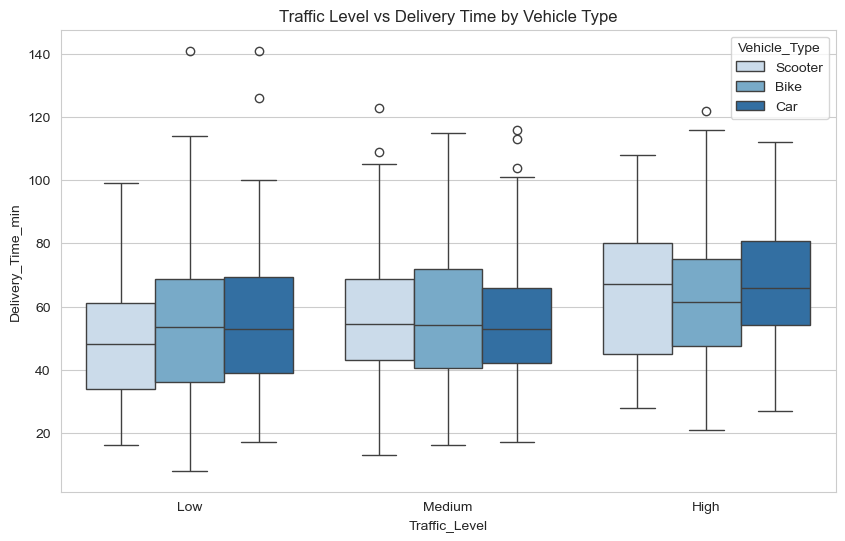

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Traffic_Level',
    y='Delivery_Time_min',
    hue='Vehicle_Type',
    palette='Blues'
)

plt.title('Traffic Level vs Delivery Time by Vehicle Type')
plt.show()

**INTERPRETASI** : Diagram grouped boxplot memperlihatkan bahwa peningkatan tingkat kemacetan (Traffic_Level) secara konsisten menaikkan median waktu pengiriman (Delivery_Time_min) pada semua jenis kendaraan (Scooter, Bike, dan Car), dari sekitar 48–54 menit pada tingkat Low menjadi 60–67 menit pada tingkat High. Di dalam tiap tingkat kemacetan yang sama, performa ketiga jenis kendaraan tergolong cukup berimbang tanpa perbedaan durasi yang drastis; hanya saja pada lalu lintas padat (High), Scooter dan Car mencatatkan median waktu tempuh yang sedikit lebih tinggi dibanding Bike. Selain itu, outlier keterlambatan ekstrem melebihi 120–140 menit justru lebih banyak ditemukan pada tingkat kemacetan Low dan Medium, mengindikasikan adanya faktor kendala eksternal lain di luar situasi jalanan.

#### 3. Weather dan Traffic --> Delivery time

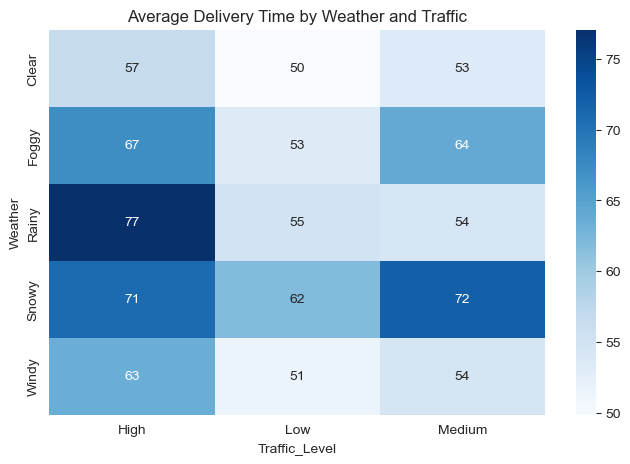

In [52]:
pivot = pd.pivot_table(
    df,
    values='Delivery_Time_min',
    index='Weather',
    columns='Traffic_Level',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='Blues'
)

plt.title('Average Delivery Time by Weather and Traffic')
plt.show()

**INTERPRETASI** : Heatmap ini menunjukkan interaksi antara kondisi cuaca (Weather) dan tingkat kemacetan (Traffic_Level) terhadap rata-rata waktu pengiriman, di mana kombinasi cuaca hujan (Rainy) dan lalu lintas padat (High) menghasilkan waktu pengiriman terlama mencapai rata-rata 77 menit. Kondisi bersalju (Snowy) juga secara konsisten menyebabkan waktu pengiriman yang tinggi di semua tingkat kemacetan (62–72 menit). Sebaliknya, pengiriman tercepat terjadi pada cuaca cerah (Clear) dengan lalu lintas lancar (Low) yang hanya membutuhkan rata-rata 50 menit. Secara umum, efek cuaca buruk (seperti hujan dan salju) akan semakin memperparah keterlambatan saat dipadukan dengan tingkat kemacetan jalan yang tinggi.

#### 4. Delay level ana

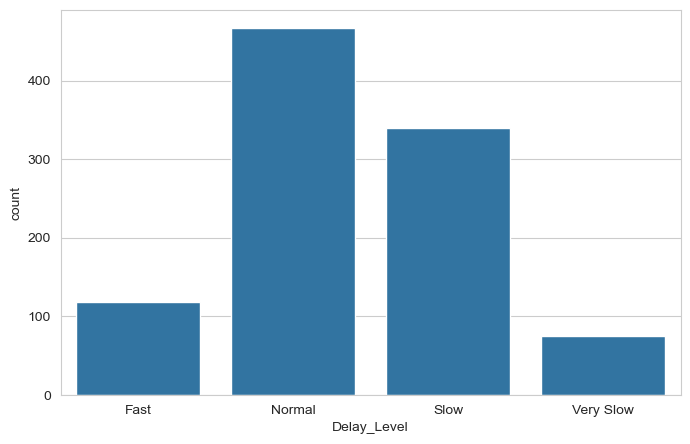

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='Delay_Level',
    order=[
        'Fast',
        'Normal',
        'Slow',
        'Very Slow'
    ]
)

plt.show()

**INTERPRETASI** : Diagram batang menunjukkan bahwa mayoritas pengiriman berada pada kategori Normal dengan frekuensi tertinggi mencapai lebih dari 450 kejadian, diikuti oleh kategori Slow di kisaran 340 kejadian. Pengiriman yang masuk dalam kategori ekstrem seperti Fast (sangat cepat) dan Very Slow (sangat lambat) tergolong jauh lebih sedikit, masing-masing berkisar sekitar 115 dan 75 kejadian. Secara umum, data mengindikasikan bahwa sebagian besar proses pengiriman berjalan sesuai standar waktu acuan (Normal), meskipun porsi pengiriman yang mengalami keterlambatan sedang (Slow) masih terbilang lumayan signifikan.

### 8. Insight dan Interpretasi

#### 1. Jarak Pengiriman menjadi faktor yang paling berpengaruh terhadap Delivery Time

Berdasarkan scatterplot, pairplot, dan heatmap korelasi, variabel Distance_km menunjukkan hubungan positif paling kuat terhadap Delivery_Time_min dibandingkan variabel numerik lainnya.

**Temuan**
- Semakin jauh jarak pengiriman, semakin lama waktu pengiriman.
- Korelasi Distance_km terhadap Delivery_Time_min merupakan yang tertinggi pada analisis korelasi.
- Kelompok pengiriman dengan kategori Very Long Distance memiliki waktu pengiriman yang jauh lebih tinggi dibanding kategori jarak pendek.

**Interpretasi Bisnis** :
Jarak merupakan faktor operasional utama yang menentukan lamanya pengiriman. Semakin jauh lokasi pelanggan dari restoran, semakin besar waktu perjalanan yang dibutuhkan kurir.

**Implikasi** :
Perusahaan perlu mengoptimalkan penempatan mitra restoran dan distribusi kurir agar pesanan dapat diproses dari lokasi yang lebih dekat dengan pelanggan.

#### 2. Tingkat kemacetan memiliki dampak besar terhadap keterlambatan pengiriman

Analisis boxplot Traffic_Level dan grouped boxplot Traffic × Vehicle menunjukkan pola yang sangat konsisten bahwa peningkatan kemacetan menyebabkan kenaikan waktu pengiriman.

**Temuan**
- Delivery time meningkat secara bertahap dari kondisi Low Traffic ke Medium Traffic hingga High Traffic.
- Pada seluruh jenis kendaraan, kondisi High Traffic selalu menghasilkan delivery time yang lebih tinggi dibanding kondisi lainnya.
- Pengaruh kemacetan terlihat lebih kuat dibandingkan pengaruh jenis kendaraan.

**Interpretasi Bisnis** :
Kemacetan lalu lintas menjadi faktor eksternal yang sulit dikendalikan namun memiliki dampak besar terhadap performa pengiriman.

**Implikasi** :
Perusahaan dapat menerapkan sistem prediksi waktu pengiriman yang menyesuaikan kondisi lalu lintas secara real-time serta meningkatkan jumlah kurir pada area dengan tingkat kemacetan tinggi.

#### 3. Cuaca buruk meningkatkan resiko pengiriman lebih lama

Berdasarkan boxplot Weather dan heatmap Weather × Traffic, kondisi cuaca menunjukkan pengaruh terhadap waktu pengiriman.

**Temuan**
- Cuaca Snowy dan Rainy menghasilkan median delivery time yang lebih tinggi dibanding kondisi Clear.
- Kombinasi cuaca buruk dan tingkat kemacetan tinggi menghasilkan rata-rata delivery time tertinggi.

**Interpretasi Bisnis** :
Cuaca buruk dapat memperlambat mobilitas kurir serta meningkatkan risiko perjalanan sehingga waktu pengiriman menjadi lebih lama.

**Implikasi** :
Perusahaan dapat memberikan estimasi waktu tambahan pada kondisi cuaca buruk agar ekspektasi pelanggan lebih realistis.

#### 4. Waktu persiapan makanan berkontribusi terhadap delivery time, namun pemgaruhnya relatif lebih kecil

Analisis scatterplot menunjukkan adanya hubungan positif antara Preparation_Time_min dan Delivery_Time_min, tetapi korelasinya tidak sekuat Distance_km.

**Temuan**
- Semakin lama waktu persiapan makanan, semakin tinggi total delivery time.
- Hubungan yang terbentuk relatif lemah dibanding pengaruh jarak dan kemacetan.

**Interpretasi Bisnis** :
Keterlambatan pengiriman tidak hanya disebabkan oleh perjalanan kurir, tetapi juga dapat dipengaruhi oleh proses operasional di restoran.

**Implikasi** :
Restoran perlu menjaga efisiensi proses persiapan pesanan terutama pada jam sibuk agar total waktu layanan dapat ditekan.

#### 5. Pengalaman kuris bukan faktor utama dalam menentukan delivery time

Scatterplot dan heatmap menunjukkan bahwa pengalaman kurir memiliki hubungan yang sangat lemah terhadap delivery time.

**Temuan**
Tidak terlihat pola yang kuat antara peningkatan pengalaman kurir dengan penurunan delivery time.
Kurir junior maupun senior memiliki sebaran delivery time yang relatif mirip.

**Interpretasi Bisnis** :
Faktor eksternal seperti jarak, kemacetan, dan cuaca memiliki pengaruh yang lebih besar dibandingkan pengalaman kurir.

**Implikasi** :
Peningkatan performa pengiriman sebaiknya lebih difokuskan pada optimasi operasional dan penugasan kurir dibanding hanya mengandalkan pengalaman kurir.

#### 6. Mayoritas pengiriman berada pada kategori normal, namun terdapat resiko keterlambatan pada kondisi tertentu

Berdasarkan analisis Delay_Level:

**Temuan** :
- Mayoritas pesanan berada pada kategori Normal.
- Sebagian pesanan masuk kategori Slow dan Very Slow.
- Pengiriman yang sangat lambat umumnya terjadi pada kombinasi:
    - Jarak jauh
    - Kemacetan tinggi
    - Cuaca buruk
      
**Interpretasi Bisnis** :
Secara umum operasional pengiriman sudah berjalan cukup baik, namun terdapat kelompok kondisi tertentu yang berisiko menyebabkan keterlambatan signifikan.

**Implikasi** :
Perusahaan dapat membuat sistem early warning untuk mendeteksi pesanan berisiko tinggi mengalami keterlambatan.

### KESIMPULAN UTAMA

Berdasarkan seluruh hasil analisis, faktor yang paling mempengaruhi waktu pengiriman makanan adalah:

1. Distance_km (Jarak Pengiriman) → faktor paling dominan.
2. Traffic_Level (Kemacetan Lalu Lintas) → faktor operasional utama.
3. Weather (Kondisi Cuaca) → memperburuk performa pengiriman pada kondisi tertentu.
4. Preparation_Time_min → berpengaruh namun tidak sebesar jarak dan kemacetan.
5. Courier_Experience_yrs → pengaruh relatif kecil terhadap delivery time.

Secara keseluruhan, keterlambatan pengiriman lebih banyak dipengaruhi oleh faktor operasional dan lingkungan dibandingkan karakteristik kurir. Oleh karena itu, strategi peningkatan layanan sebaiknya difokuskan pada optimasi area layanan, manajemen lalu lintas, estimasi waktu berbasis kondisi aktual, serta peningkatan efisiensi proses persiapan pesanan.

### 9. Mechine Learning Modeling

In [57]:
# Membuat dataframe baru khusus untuk machine learning
df_model = df_clean.copy()

In [58]:
# Mengecek jumlah baris dan kolom data
print(df_model.shape)

(1000, 12)


#### 1. Tahap 1 : Memeriksa kolom

In [59]:
df_model.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min', 'Distance_Category', 'Experience_Group',
       'Delay_Level'],
      dtype='object')

#### 2. Tahap 2 : Menentukan target

In [62]:
# menentukan kolom target dalam pemodelan
target = 'Delivery_Time_min'

In [63]:
# membuat target
y = df_model[target]

#### 3. Tahap 3 : Menentukan feature

**Keterangan** :
- Tidak menggunakan kolom **Order_id** hanya identifier karena tidak memiliki nilai prediktif
- Tidak menggunakan kolom **Delivery_Time_min** karena ini target dan tidak boleh masuk feature
- Tidak menggunakan kolom **Delay_Level** karena dibuat dari kolom Delivery_Time_min karena jika dipakai akan terjadi data leakage

In [64]:
# membuat feature
X = df_model.drop(
    columns=[
        'Order_ID',
        'Delivery_Time_min',
        'Delay_Level'
    ])

#### 4. Tahap 4 : Encoding variabel kategorikal

In [65]:
# membuat dataframe baru kembali
X_encoded = pd.get_dummies(X, drop_first=True)

In [66]:
# melakukan pengecekan
X_encoded.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Unknown,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Traffic_Level_Unknown,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Time_of_Day_Unknown,Vehicle_Type_Car,Vehicle_Type_Scooter,Distance_Category_Medium,Distance_Category_Long,Distance_Category_Very Long,Experience_Group_Mid-Level,Experience_Group_Senior
0,7.93,12,1.0,False,False,False,False,True,True,False,False,False,False,False,False,False,True,True,False,False,False,False
1,16.42,20,2.0,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
2,9.52,28,1.0,True,False,False,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False
3,7.44,5,1.0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False
4,19.03,16,5.0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False


In [67]:
# mengecek data encoding
X_encoded.shape

(1000, 22)

#### 5. Tahap 5 : Train test split

In [69]:
# memisahkan data train dan test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
# mengecek kembali
print(X_train.shape)
print(X_test.shape)

(800, 22)
(200, 22)


#### 6. Tahap 6 : Baseline model (linear regression)

In [71]:
# membuat baseline terlebih dahulu
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

#### 7. Tahap 7 : Evaluasi linear regression

In [72]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr)

rmse_lr = mean_squared_error(
    y_test,
    y_pred_lr) ** 0.5

r2_lr = r2_score(
    y_test,
    y_pred_lr)

print("Linear Regression")
print("MAE :", round(mae_lr,2))
print("RMSE:", round(rmse_lr,2))
print("R2  :", round(r2_lr,2))

Linear Regression
MAE : 5.94
RMSE: 8.8
R2  : 0.83


#### 8. Tahap 8 : Random forest regressor (model utama)

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42)

rf.fit(
    X_train,
    y_train)

y_pred_rf = rf.predict(
    X_test)

#### 9. Tahap 9 : Evaluasi random forest

In [74]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf)

print("Random Forest")
print("MAE :", round(mae_rf,2))
print("RMSE:", round(rmse_rf,2))
print("R2  :", round(r2_rf,2))

Random Forest
MAE : 7.11
RMSE: 10.32
R2  : 0.76


#### 10. Tahap 10 : Membandingkan kedua model

In [75]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'],
    'MAE': [
        mae_lr,
        mae_rf],
    'RMSE': [
        rmse_lr,
        rmse_rf],
    'R2': [
        r2_lr,
        r2_rf
    ]})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,5.943546,8.804385,0.827058
1,Random Forest,7.107842,10.322154,0.762293


INTERPRETASI :
- Model Linear Regression menjadi pilihan terbaik hal ini dikarena oleh hal berikut :
    - Nilai MAE linear regression lebih kecil
    - Nilai RMSE linear regression lebih kecil
    - Nilai R^2 linear regression lebih besar
- Linear regression mampu menjelaskan sekitar 82,7% variasi delivery time dan memberikan error prediksi yang lebih rendah dibandingkan random forest

#### 11. Tahap 11 : Analisis koefisien linear regression

In [76]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_})

coef_df.sort_values(
    by='Coefficient',
    ascending=False)

,Feature,Coefficient
5,Weather_Snowy,9.617458
14,Time_of_Day_Unknown,8.103458
3,Weather_Foggy,6.456723
6,Weather_Unknown,5.384958
4,Weather_Rainy,5.196696
0,Distance_km,3.207097
7,Weather_Windy,1.337256
1,Preparation_Time_min,0.982547
11,Time_of_Day_Evening,0.908582
15,Vehicle_Type_Car,0.587767


In [79]:
# mengecek data 10 terbesar
coef_df.sort_values(
    by='Coefficient',
    ascending=False).head(10)

,Feature,Coefficient
5,Weather_Snowy,9.617458
14,Time_of_Day_Unknown,8.103458
3,Weather_Foggy,6.456723
6,Weather_Unknown,5.384958
4,Weather_Rainy,5.196696
0,Distance_km,3.207097
7,Weather_Windy,1.337256
1,Preparation_Time_min,0.982547
11,Time_of_Day_Evening,0.908582
15,Vehicle_Type_Car,0.587767


**INTERPRETASI** :
- Cuaca buruk merupakan faktor yang paling memperlambat pengiriman.
- Jarak pengiriman memiliki pengaruh yang signifikan terhadap peningkatan Delivery Time.
- Waktu persiapan makanan berkontribusi langsung terhadap lamanya pengiriman.
- Faktor operasional dan kondisi eksternal lebih dominan dibandingkan karakteristik kendaraan.

In [80]:
coef_df.sort_values(
    by='Coefficient').head(10)

,Feature,Coefficient
8,Traffic_Level_Low,-11.222716
9,Traffic_Level_Medium,-5.731909
10,Traffic_Level_Unknown,-3.800580
19,Distance_Category_Very Long,-3.533238
21,Experience_Group_Senior,-2.795243
13,Time_of_Day_Night,-1.244457
16,Vehicle_Type_Scooter,-0.876423
20,Experience_Group_Mid-Level,-0.874121
12,Time_of_Day_Morning,-0.870953
18,Distance_Category_Long,-0.514564


**INTERPRETASI** :
- Tingkat kemacetan merupakan faktor yang paling memengaruhi percepatan pengiriman.
- Kurir yang lebih berpengalaman mampu menyelesaikan pengiriman lebih cepat.
- Pengiriman pada malam hari cenderung lebih efisien dibandingkan waktu lainnya.
- Kendaraan roda dua (scooter) memiliki keunggulan dalam mendukung pengiriman yang lebih cepat.

#### 12. Tahap 12 : Visualisai koefisien

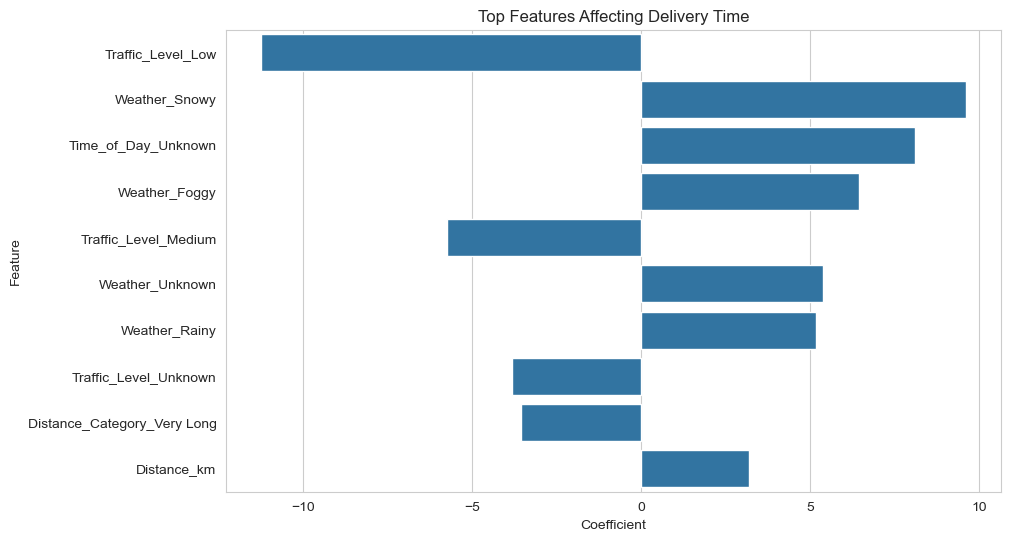

In [81]:
coef_plot = coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_plot,
    x='Coefficient',
    y='Feature'
)

plt.title('Top Features Affecting Delivery Time')
plt.show()

#### 13. Tahap 13 : Predicted vs Actual

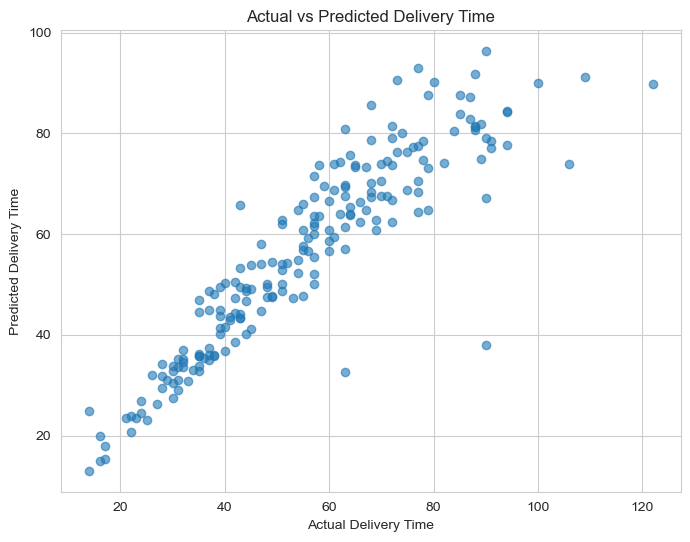

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.6
)

plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted Delivery Time')

plt.show()

**INTERPRETASI** : Scatter plot menunjukkan hubungan yang kuat antara nilai aktual dan nilai prrdiksi sehingga model mampu menangkap pola utama dalam data dengan baik

#### 14. Tahap 14 : Residual analysis

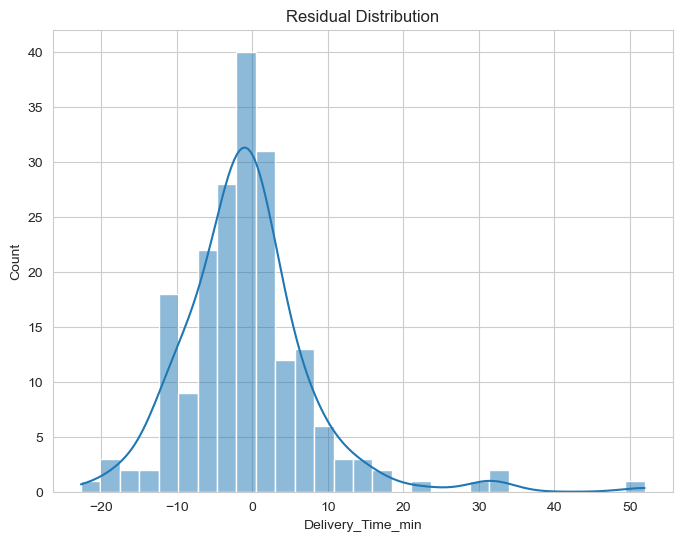

In [83]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True)

plt.title('Residual Distribution')
plt.show()

**INTERPRETASI** : 
- Nilai terpusat di sekitar nol
- Bentuk mendkati normal
- Tidak terlalu skew
- Hal ini menunjukkan bahwa sebagian besat error prediksi relatif kecil dan tidak menunjukkan pola sistematis yang signifikan

#### 15. Modelling Conclusion

**KESIMPULAN MODELING** : Dua model regresi diuji untuk memprediksi Delivery Time, yaitu Linear Regression dan Random Forest Regressor. Berdasarkan hasil evaluasi, Linear Regression memberikan performa terbaik dengan MAE sebesar 5.94 menit, RMSE sebesar 8.80 menit, dan R² sebesar 0.827. Oleh karena itu, Linear Regression dipilih sebagai model final karena mampu memberikan prediksi yang lebih akurat dibandingkan Random Forest pada dataset ini.

Model menunjukkan bahwa faktor yang paling mempengaruhi Delivery Time adalah:
1. Traffic Level
2. Weather Condition
3. Distance
4. Preparation Time
5. Courier Experience

Hasil ini konsisten dengan temuan EDA yang menunjukkan bahwa kondisi operasional dan lingkungan memiliki pengaruh yang lebih besar dibanding karakteristik kurir.